# NYC Air Pollution & Disease: A Borough-Level Analysis

**Research Question:** Are neighborhoods with higher truck traffic and pollution levels associated with higher rates of asthma ER visits, cardiovascular hospitalizations, and pollution-related deaths across NYC's 5 boroughs?

**Data Sources:**
- NYC Open Data `c3uy-2p5r` — Air Quality & Health Impacts (2005–2024)
- NYC Open Data `ebe7-6eah` — PM2.5 Attributable Asthma ED Visits
- EPA AirNow API — Real-time AQI by borough
- PurpleAir API — Community sensors filling Brooklyn & Manhattan gaps

---

## Dataset Overview

| Variable | Type | Role |
|---|---|---|
| Asthma ER visits (PM2.5) | Quantitative | Dependent |
| Cardiovascular hospitalizations (PM2.5) | Quantitative | Dependent |
| Respiratory hospitalizations (PM2.5) | Quantitative | Dependent |
| Deaths due to PM2.5 | Quantitative | Dependent |
| Cardiac & respiratory deaths (Ozone) | Quantitative | Dependent |
| Fine particles PM2.5 (mcg/m³) | Quantitative | Independent |
| Nitrogen dioxide NO2 (ppb) | Quantitative | Independent |
| Ozone O3 (ppb) | Quantitative | Independent |
| Annual truck miles traveled | Quantitative | Independent |
| Current AQI (AirNow) | Quantitative | Independent |
| Current PM2.5 (PurpleAir) | Quantitative | Independent |
| Borough | Categorical | Independent |
| Time Period | Categorical | Independent |

---
## Section 1 — Setup & Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

BOROUGH_COLORS = {
    'Manhattan':     '#4A90C4',
    'Bronx':         '#7B68EE',
    'Brooklyn':      '#48A999',
    'Queens':        '#5B8C5A',
    'Staten Island': '#8B6F47',
}
PALETTE      = list(BOROUGH_COLORS.values())
HEATMAP_CMAP = 'PuBuGn'
NYC_BOROUGHS = ['Manhattan','Bronx','Brooklyn','Queens','Staten Island']

sns.set_palette(PALETTE)
print('Libraries loaded')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')
print(f'  palette : blues, teals, aquas, purples, violets, greens, browns')

Libraries loaded
  pandas  : 3.0.3
  numpy   : 2.4.6
  palette : blues, teals, aquas, purples, violets, greens, browns


---
## Section 2 — Load Data

> Run these first in your terminal:
> ```bash
> python src/dataingestion.py
> python src/datamerge.py
> ```

In [3]:
# Use absolute path — works regardless of where notebook is opened from
PROJECT_ROOT = r'C:\Users\User 1\Desktop\Git\TKH\Pollution&DiseaseNYC'
DATA_DIR     = os.path.join(PROJECT_ROOT, 'Data')
MERGED_CSV = os.path.join(DATA_DIR, 'merged_final.csv')
RAW_CSV    = os.path.join(DATA_DIR, 'Air_Quality_and_Health_Impacts.csv')

if os.path.exists(MERGED_CSV):
    df = pd.read_csv(MERGED_CSV)
    print(f'Loaded merged_final.csv: {df.shape[0]} rows x {df.shape[1]} columns')
else:
    print('merged_final.csv not found — loading raw CSV')
    df_raw = pd.read_csv(RAW_CSV)
    df_raw.columns = [c.strip().lower().replace(' ','_') for c in df_raw.columns]
    df = df_raw[df_raw['geo_type_name']=='Borough'].copy()
    df = df[df['geo_place_name'].isin(NYC_BOROUGHS)].copy()

raw = pd.read_csv(RAW_CSV)
raw.columns = [c.strip().lower().replace(' ','_') for c in raw.columns]
raw['data_value'] = pd.to_numeric(raw['data_value'], errors='coerce')
raw['start_date'] = pd.to_datetime(raw['start_date'], errors='coerce')
raw['year'] = raw['start_date'].dt.year
boro = raw[(raw['geo_type_name']=='Borough') & (raw['geo_place_name'].isin(NYC_BOROUGHS))].copy()

print(f'Raw data: {len(boro)} borough-level rows')
df.head()

Loaded merged_final.csv: 105 rows x 14 columns
Raw data: 910 borough-level rows


,borough,time_period,year,asthma_emergency_department_visits_due_to_pm25,asthma_hospitalizations_due_to_ozone,cardiac_and_respiratory_deaths_due_to_ozone,cardiovascular_hospitalizations_due_to_pm25_age_40plus,deaths_due_to_pm25,fine_particles_pm_25,nitrogen_dioxide_no2,ozone_o3,respiratory_hospitalizations_due_to_pm25_age_20plus,airnow_avg_aqi,purpleair_avg_pm25
0,Bronx,2005-2007,2005,167.40,23.75,3.90,31.30,76.50,NaN,NaN,NaN,30.80,36.00,14.18
1,Bronx,2009,2009,NaN,NaN,NaN,NaN,NaN,11.95,24.88,25.30,NaN,36.00,14.18
2,Bronx,2009-2011,2009,97.60,25.75,4.10,18.80,55.00,NaN,NaN,NaN,20.60,36.00,14.18
3,Bronx,2010,2010,NaN,NaN,NaN,NaN,NaN,11.07,21.99,33.16,NaN,36.00,14.18
4,Bronx,2011,2011,NaN,NaN,NaN,NaN,NaN,12.11,23.08,32.91,NaN,36.00,14.18


---
## Section 3 — Exploratory Data Analysis

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

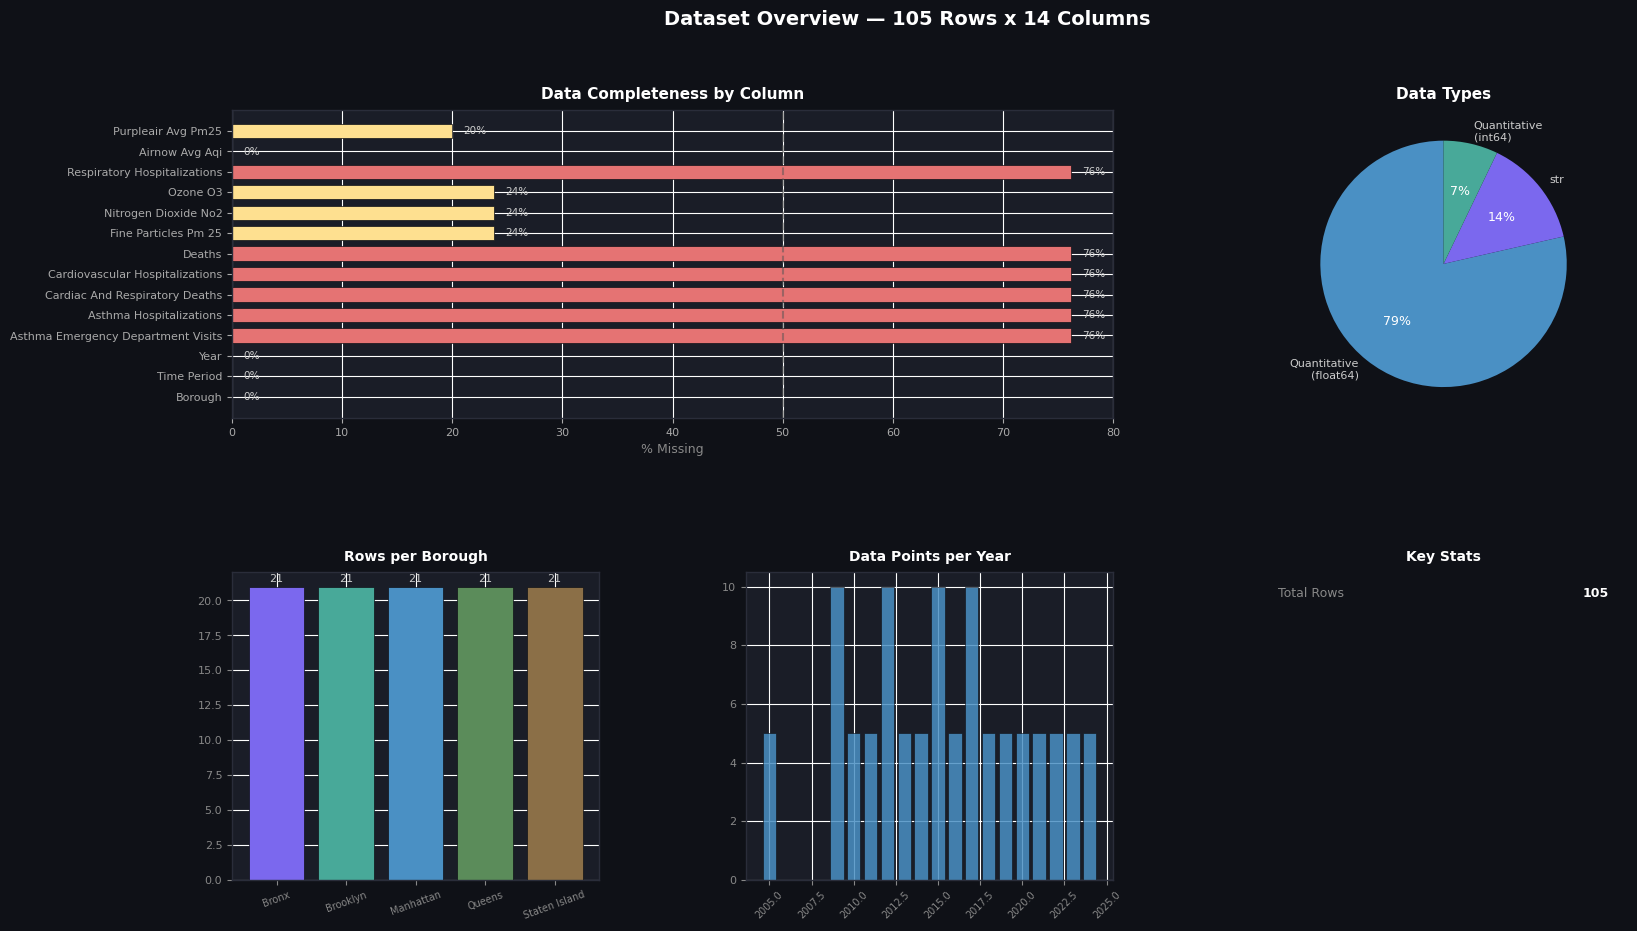

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Dataset Overview — 105 Rows x 14 Columns',
             fontsize=14, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

# ── 1. Missing values bar chart ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#1a1d27')
for spine in ax1.spines.values():
    spine.set_edgecolor('#2a2d3a')

cols = df.columns.tolist()
nulls = df.isnull().sum().tolist()
pcts  = [n/len(df)*100 for n in nulls]
colors_bar = ['#E57373' if p > 50 else '#48A999' if p == 0 else '#fee090'
              for p in pcts]
short_cols = [c.replace('_due_to_pm25','').replace('_due_to_ozone','')
               .replace('_age_40plus','').replace('_age_20plus','')
               .replace('_',' ').title() for c in cols]

bars = ax1.barh(short_cols, pcts, color=colors_bar, edgecolor='#0f1117', height=0.7)
ax1.set_xlabel('% Missing', fontsize=9, color='#888')
ax1.set_title('Data Completeness by Column', fontsize=11,
              fontweight='bold', color='white', pad=8)
ax1.tick_params(colors='#aaa', labelsize=8)
ax1.axvline(50, color='#555', linestyle='--', alpha=0.5)
for bar, pct in zip(bars, pcts):
    ax1.text(pct + 1, bar.get_y() + bar.get_height()/2,
             f'{pct:.0f}%', va='center', fontsize=7.5, color='#ccc')

# ── 2. Data type donut ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#1a1d27')
type_counts = df.dtypes.astype(str).value_counts()
wedge_colors = ['#4A90C4','#7B68EE','#48A999']
wedges, texts, autotexts = ax2.pie(
    type_counts.values,
    labels=[t.replace('float64','Quantitative\n(float64)')
             .replace('int64','Quantitative\n(int64)')
             .replace('object','Categorical\n(string)')
            for t in type_counts.index],
    autopct='%1.0f%%',
    colors=wedge_colors[:len(type_counts)],
    startangle=90,
    textprops={'color':'#ccc','fontsize':8}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(9)
ax2.set_title('Data Types', fontsize=11, fontweight='bold',
              color='white', pad=8)

# ── 3. Row counts per borough ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#1a1d27')
for spine in ax3.spines.values():
    spine.set_edgecolor('#2a2d3a')
boro_counts = df['borough'].value_counts()
bar_colors  = [BOROUGH_COLORS.get(b,'#4A90C4') for b in boro_counts.index]
ax3.bar(boro_counts.index, boro_counts.values,
        color=bar_colors, edgecolor='#0f1117')
ax3.set_title('Rows per Borough', fontsize=10, fontweight='bold',
              color='white', pad=8)
ax3.tick_params(colors='#888', labelsize=7, axis='x', rotation=20)
ax3.tick_params(colors='#888', labelsize=8, axis='y')
for i, v in enumerate(boro_counts.values):
    ax3.text(i, v+0.3, str(v), ha='center', fontsize=8, color='#ccc')

# ── 4. Year range timeline ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#1a1d27')
for spine in ax4.spines.values():
    spine.set_edgecolor('#2a2d3a')
year_counts = df['year'].value_counts().sort_index()
ax4.bar(year_counts.index, year_counts.values,
        color='#4A90C4', edgecolor='#0f1117', alpha=0.85)
ax4.set_title('Data Points per Year', fontsize=10, fontweight='bold',
              color='white', pad=8)
ax4.tick_params(colors='#888', labelsize=7, axis='x', rotation=45)
ax4.tick_params(colors='#888', labelsize=8, axis='y')

# ── 5. Key stats summary ───────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#1a1d27')
ax5.axis('off')
stats = [
    ('Total Rows',       '105'),
    ('Columns',          '14'),
    ('Boroughs',         '5'),
    ('Years Covered',    '2005-2024'),
    ('API Sources',      '4'),
    ('Quantitative Vars','12'),
    ('Categorical Vars', '2'),
    ('Avg PM2.5',        f"{df['fine_particles_pm_25'].mean():.1f} mcg/m3"),
    ('Avg AQI (live)',   f"{df['airnow_avg_aqi'].mean():.1f}"),
]
ax5.set_title('Key Stats', fontsize=10, fontweight='bold',
              color='white', pad=8)
for i, (label, value) in enumerate(stats):
    y = 0.92 - i * 0.11
    ax5.text(0.05, y, label, transform=ax5.transAxes,
             fontsize=9, color='#888')
    ax5.text(0.95, y, value, transform=ax5.transAxes,
             fontsize=9, color='white', ha='right', fontweight='bold')
    ax5.axhline(y - 0.04, color='#2a2d3a', linewidth=0.5,
                transform=ax5.transAxes, xmin=0.02, xmax=0.98)

plt.savefig(os.path.join(PROJECT_ROOT, 'Data', 'dataset_overview.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved dataset_overview.png')

In [ ]:
df.describe()

---
## Section 4 — Charts & Visualizations
### 4a. PM2.5 Levels by Borough Over Time

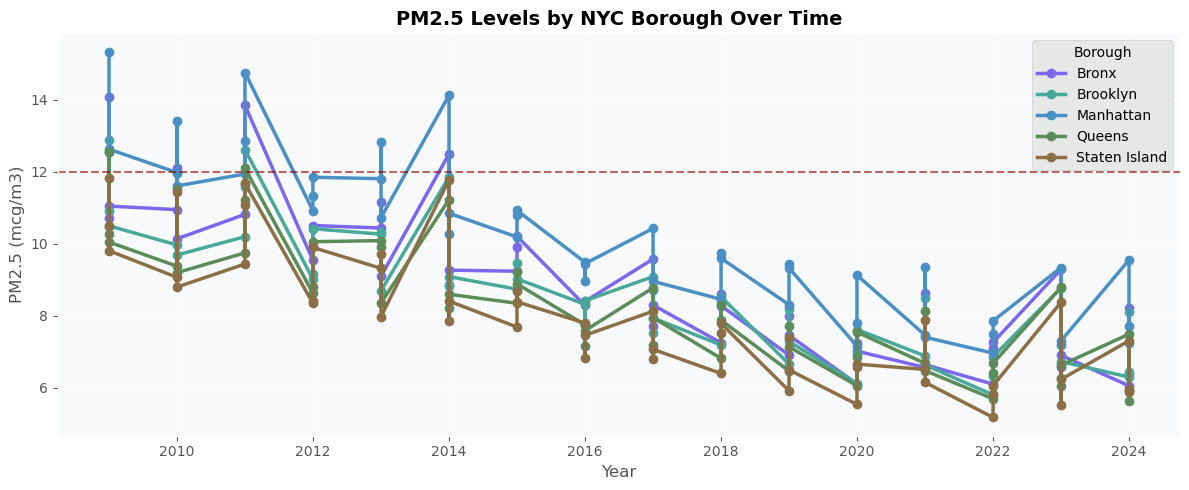

In [6]:
pm25 = boro[boro['name'] == 'Fine particles (PM 2.5)'].copy()

fig, ax = plt.subplots(figsize=(12, 5))
for borough, group in pm25.groupby('geo_place_name'):
    g = group.sort_values('start_date')
    ax.plot(g['start_date'], g['data_value'],
            marker='o', label=borough, linewidth=2.5,
            color=BOROUGH_COLORS.get(borough, '#4A90C4'))

ax.set_title('PM2.5 Levels by NYC Borough Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('PM2.5 (mcg/m3)')
ax.legend(title='Borough', framealpha=0.9)
ax.axhline(12, color='#8B0000', linestyle='--', alpha=0.6, label='EPA standard (12 mcg/m3)')
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

### 4b. All Health Outcomes Over Time by Borough (2005-2024)

FileNotFoundError: [Errno 2] No such file or directory: '..\\Data\\all_health_outcomes_trends.png'

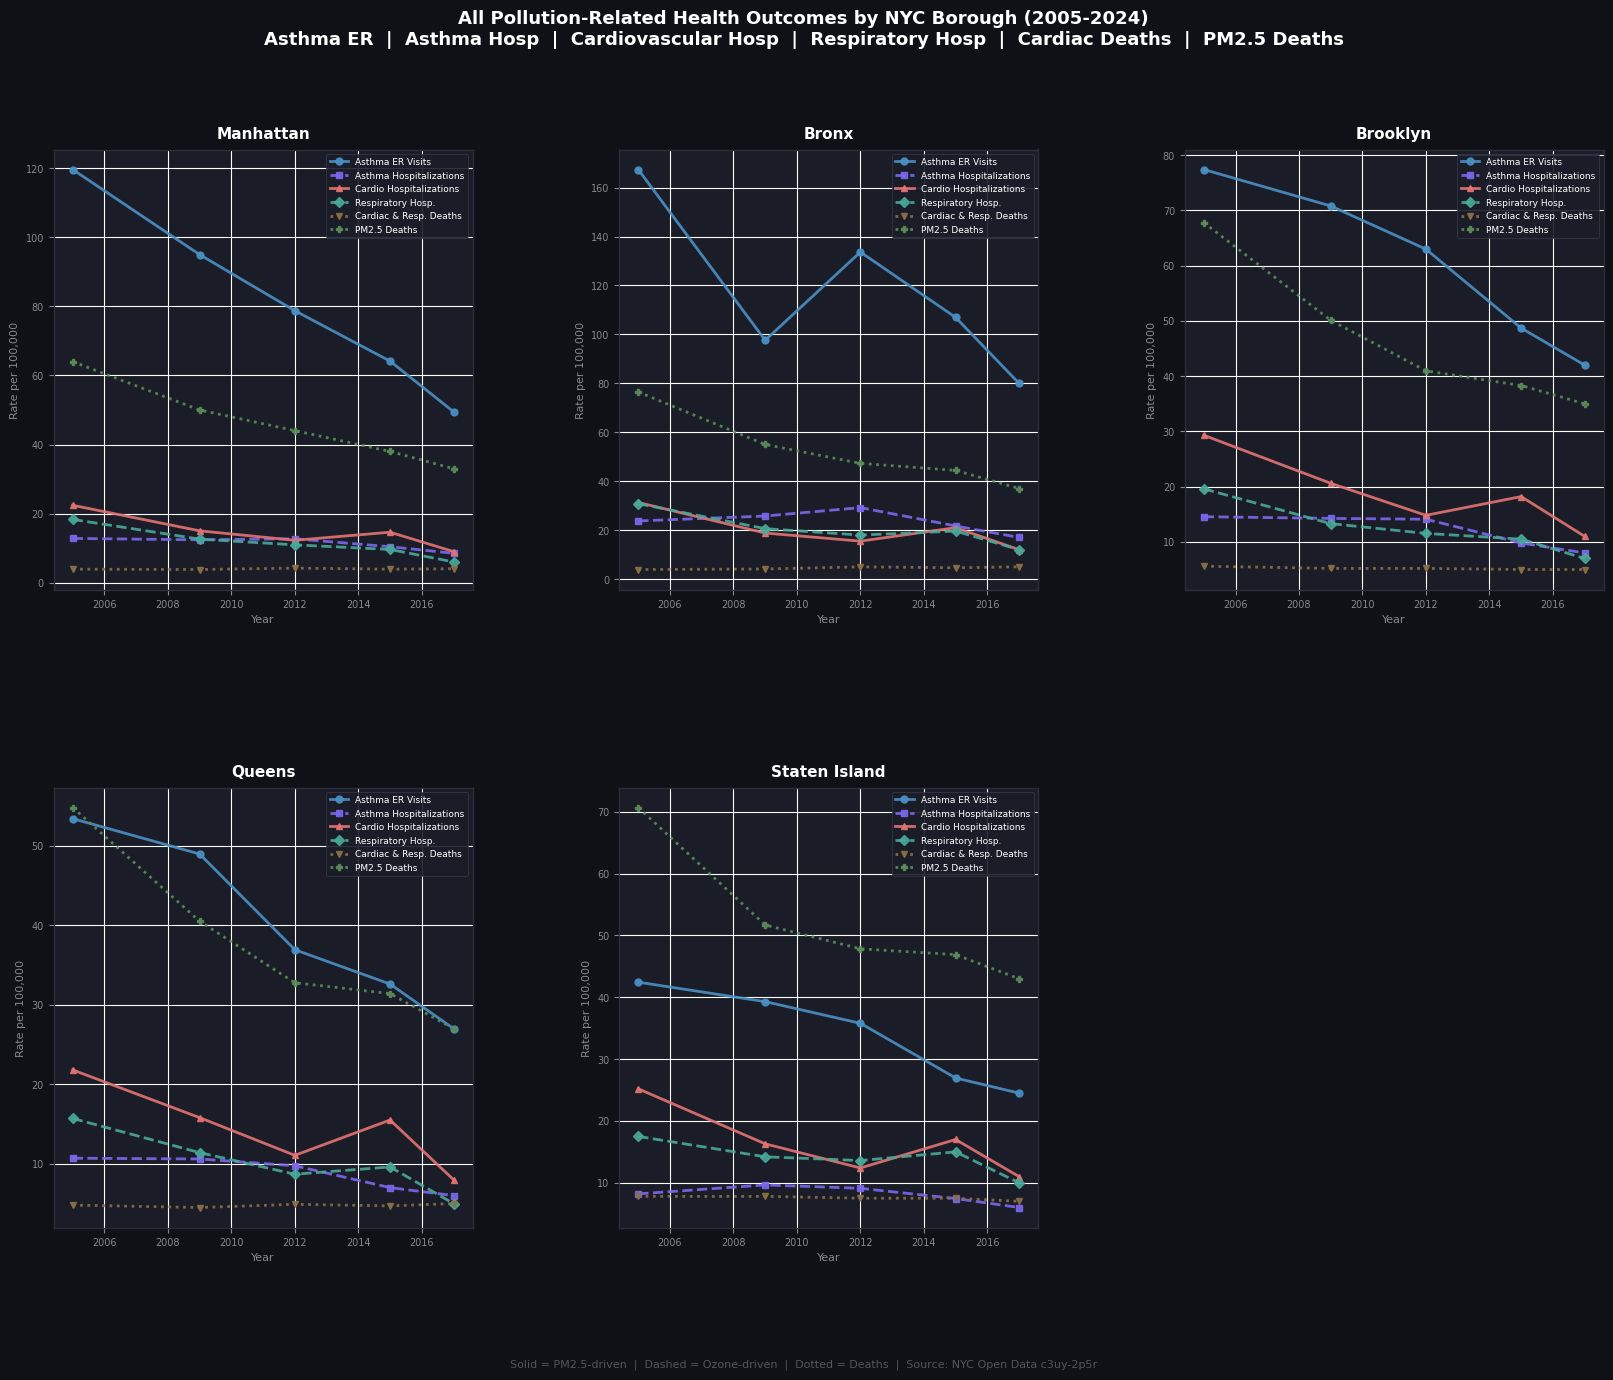

In [7]:
health_indicators = {
    'Asthma emergency department visits due to PM2.5':         ('Asthma ER Visits',       '-',  'o'),
    'Asthma hospitalizations due to Ozone':                    ('Asthma Hospitalizations', '--', 's'),
    'Cardiovascular hospitalizations due to PM2.5 (age 40+)':  ('Cardio Hospitalizations', '-',  '^'),
    'Respiratory hospitalizations due to PM2.5 (age 20+)':     ('Respiratory Hosp.',       '--', 'D'),
    'Cardiac and respiratory deaths due to Ozone':             ('Cardiac & Resp. Deaths',  ':',  'v'),
    'Deaths due to PM2.5':                                     ('PM2.5 Deaths',            ':',  'P'),
}
outcome_colors = ['#4A90C4','#7B68EE','#E57373','#48A999','#8B6F47','#5B8C5A']

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0f1117')
fig.suptitle(
    'All Pollution-Related Health Outcomes by NYC Borough (2005-2024)\n'
    'Asthma ER  |  Asthma Hosp  |  Cardiovascular Hosp  |  Respiratory Hosp  |  Cardiac Deaths  |  PM2.5 Deaths',
    fontsize=13, fontweight='bold', color='white', y=0.98
)

gs   = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2]),
        fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
fig.add_subplot(gs[1,2]).set_visible(False)

for ax, borough in zip(axes, NYC_BOROUGHS):
    ax.set_facecolor('#1a1d27')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2d3a')
    for (indicator, (label, ls, marker)), color in zip(health_indicators.items(), outcome_colors):
        subset = (
            boro[(boro['name']==indicator) & (boro['geo_place_name']==borough)]
            .groupby('year')['data_value'].mean().reset_index().sort_values('year')
        )
        if not subset.empty:
            ax.plot(subset['year'], subset['data_value'],
                    label=label, color=color, linewidth=2,
                    linestyle=ls, marker=marker, markersize=5, alpha=0.9)
    ax.set_title(borough, fontsize=11, fontweight='bold', color='white', pad=8)
    ax.set_xlabel('Year', fontsize=8, color='#888')
    ax.set_ylabel('Rate per 100,000', fontsize=8, color='#888')
    ax.tick_params(colors='#888', labelsize=7)
    ax.legend(fontsize=6.5, loc='upper right',
              facecolor='#1a1d27', edgecolor='#3a3d50',
              labelcolor='white', framealpha=0.9)

fig.text(0.5, 0.01,
    'Solid = PM2.5-driven  |  Dashed = Ozone-driven  |  Dotted = Deaths  |  Source: NYC Open Data c3uy-2p5r',
    ha='center', fontsize=8, color='#555')
plt.savefig(os.path.join('..','Data','all_health_outcomes_trends.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved all_health_outcomes_trends.png')

### 4c. Correlation Heatmap

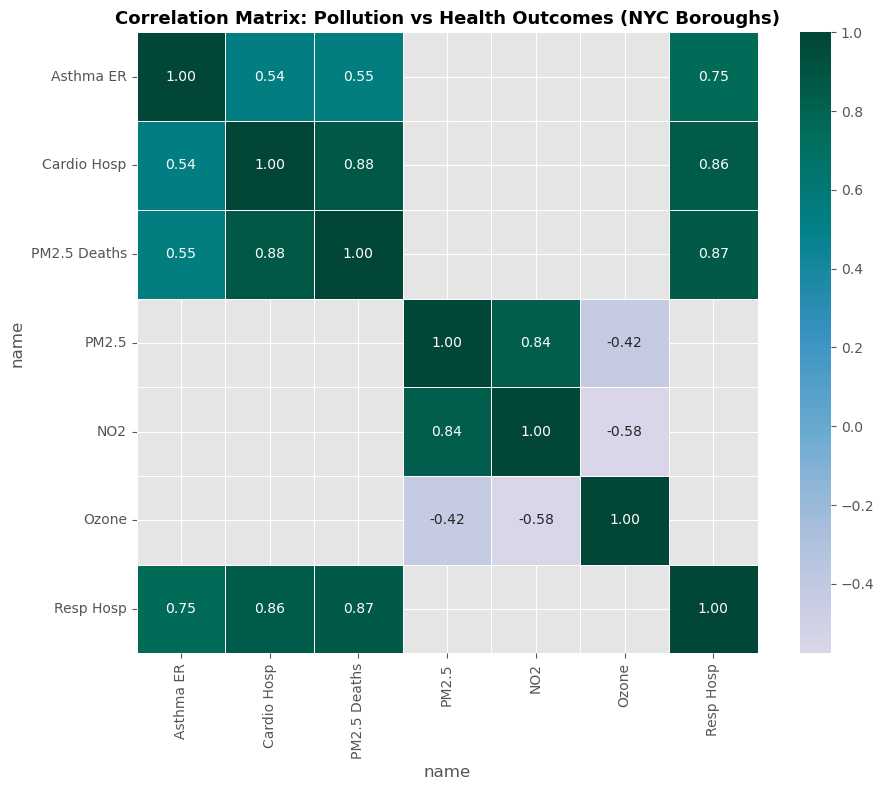

In [8]:
indicators_of_interest = [
    'Fine particles (PM 2.5)',
    'Nitrogen dioxide (NO2)',
    'Ozone (O3)',
    'Annual vehicle miles traveled (trucks)',
    'Asthma emergency department visits due to PM2.5',
    'Cardiovascular hospitalizations due to PM2.5 (age 40+)',
    'Respiratory hospitalizations due to PM2.5 (age 20+)',
    'Deaths due to PM2.5',
]
pivot_corr = boro[boro['name'].isin(indicators_of_interest)].pivot_table(
    index=['geo_place_name','time_period'], columns='name',
    values='data_value', aggfunc='mean'
)
short_names = {
    'Fine particles (PM 2.5)':                               'PM2.5',
    'Nitrogen dioxide (NO2)':                                'NO2',
    'Ozone (O3)':                                            'Ozone',
    'Annual vehicle miles traveled (trucks)':                'Truck Miles',
    'Asthma emergency department visits due to PM2.5':       'Asthma ER',
    'Cardiovascular hospitalizations due to PM2.5 (age 40+)':'Cardio Hosp',
    'Respiratory hospitalizations due to PM2.5 (age 20+)':   'Resp Hosp',
    'Deaths due to PM2.5':                                   'PM2.5 Deaths',
}
pivot_corr = pivot_corr.rename(columns=short_names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_corr.corr(), annot=True, fmt='.2f', cmap=HEATMAP_CMAP,
            center=0, square=True, ax=ax,
            annot_kws={'size':10}, linewidths=0.5, linecolor='white')
ax.set_title('Correlation Matrix: Pollution vs Health Outcomes (NYC Boroughs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4d. Real-Time AQI from AirNow by Borough

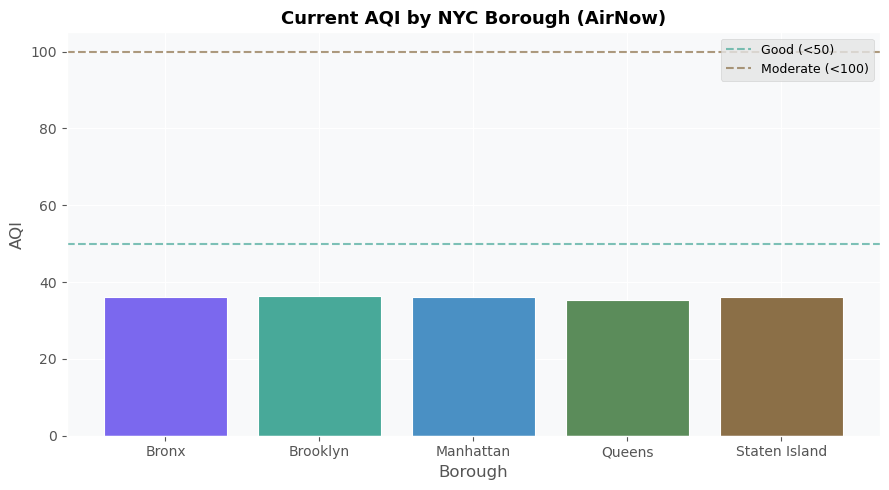

In [9]:
AIRNOW_CSV = os.path.join(DATA_DIR, 'airnow_realtime_aqi.csv')
if os.path.exists(AIRNOW_CSV):
    airnow = pd.read_csv(AIRNOW_CSV)
    airnow.columns = [c.lower() for c in airnow.columns]
    aqi_col = next((c for c in airnow.columns if 'aqi' in c), None)
    if aqi_col:
        airnow[aqi_col] = pd.to_numeric(airnow[aqi_col], errors='coerce')
        boro_aqi = airnow.groupby('borough')[aqi_col].mean().reset_index()
        fig, ax = plt.subplots(figsize=(9, 5))
        bar_colors = [BOROUGH_COLORS.get(b, '#4A90C4') for b in boro_aqi['borough']]
        ax.bar(boro_aqi['borough'], boro_aqi[aqi_col],
               color=bar_colors, edgecolor='white', linewidth=0.8)
        ax.axhline(50,  color='#48A999', linestyle='--', alpha=0.7, label='Good (<50)')
        ax.axhline(100, color='#8B6F47', linestyle='--', alpha=0.7, label='Moderate (<100)')
        ax.set_facecolor('#F8F9FA')
        ax.set_title('Current AQI by NYC Borough (AirNow)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Borough')
        ax.set_ylabel('AQI')
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()
else:
    print('AirNow CSV not found — run dataingestion.py')

---
## Section 5 — Interactive NYC Pollution & Disease Heatmap by Zip Code

Each zip code is colored **blue to red** based on AQI:
- Blue = cleaner air, lower disease rates
- Red = higher pollution, higher hospitalization rates

**Hover** over any zip code to see AQI, PM2.5, asthma ER rate, cardio hospitalization rate, truck traffic index, and infrastructure notes.

**Click** any zip code to pin its data popup.

Notable hotspots: Hunts Point 10474, Gowanus 11215/11217, Newtown Creek 11222/11378, Broadway Junction 11233, Cross Bronx 10451-10457, JFK 11430

In [10]:
import folium
import branca.colormap as cm
import requests as req
from IPython.display import display

zip_data = {
    '10001':[68,9.8, 112,48,85, 'Manhattan',    'Chelsea - Lincoln Tunnel, Javits trucks'],
    '10002':[62,9.1,  98,42,70, 'Manhattan',    'Lower East Side - FDR Drive'],
    '10003':[60,8.9,  95,40,65, 'Manhattan',    'East Village - FDR Drive'],
    '10004':[55,8.2,  88,38,72, 'Manhattan',    'Battery Park - Brooklyn Battery Tunnel'],
    '10007':[59,8.7,  93,41,78, 'Manhattan',    'City Hall - Brooklyn Bridge trucks'],
    '10009':[61,9.0,  97,42,68, 'Manhattan',    'Alphabet City - FDR Drive'],
    '10011':[64,9.4, 102,44,80, 'Manhattan',    'Chelsea waterfront - West Side Hwy'],
    '10013':[71,10.2,118,50,92, 'Manhattan',    'Tribeca - Holland Tunnel approach'],
    '10014':[65,9.5, 104,45,82, 'Manhattan',    'West Village - West Side Hwy'],
    '10018':[74,10.7,124,53,95, 'Manhattan',    "Hell's Kitchen - Lincoln Tunnel"],
    '10019':[73,10.5,122,52,93, 'Manhattan',    'Midtown West - Lincoln Tunnel, Javits'],
    '10026':[66,9.6, 108,46,78, 'Manhattan',    'Harlem - FDR Drive, truck corridor'],
    '10029':[65,9.5, 106,46,76, 'Manhattan',    'East Harlem - FDR Drive'],
    '10031':[63,9.2, 102,44,74, 'Manhattan',    'Hamilton Heights - West Side Hwy'],
    '10032':[67,9.7, 110,47,84, 'Manhattan',    'Washington Heights - GWB approach'],
    '10034':[70,10.1,116,50,88, 'Manhattan',    'Inwood - GWB, I-95 approach'],
    '10035':[67,9.7, 111,47,82, 'Manhattan',    'East Harlem - RFK Bridge, FDR'],
    '10036':[75,10.8,126,54,96, 'Manhattan',    "Hell's Kitchen - Lincoln Tunnel, Javits"],
    '10040':[69,10.0,114,49,87, 'Manhattan',    'Inwood - GWB approach'],
    '10044':[48,7.2,  78,33,20, 'Manhattan',    'Roosevelt Island - low traffic'],
    '10280':[54,8.1,  87,37,71, 'Manhattan',    'Battery Park City - West Side Hwy'],
    '10282':[56,8.3,  89,38,73, 'Manhattan',    'Battery Park City - West Side Hwy, tunnel'],
    '10451':[92,13.8,198,78,145,'Bronx','Mott Haven - Cross Bronx Expwy I-278'],
    '10452':[86,12.9,184,72,130,'Bronx','Highbridge - Major Deegan I-87'],
    '10453':[85,12.7,181,71,128,'Bronx','Morris Heights - Cross Bronx Expwy'],
    '10454':[94,14.1,204,80,148,'Bronx','Port Morris - Bruckner Expwy, waterway industrial'],
    '10455':[90,13.5,194,76,140,'Bronx','Longwood - Bruckner Expressway I-278'],
    '10456':[88,13.2,188,74,134,'Bronx','Morrisania - Major Deegan I-87'],
    '10457':[87,13.0,185,73,131,'Bronx','East Tremont - Cross Bronx Expwy'],
    '10458':[78,11.6,162,64,108,'Bronx','Belmont - Bronx River Pkwy'],
    '10459':[84,12.5,178,70,125,'Bronx','Longwood - truck routes'],
    '10460':[83,12.4,176,69,122,'Bronx','West Farms - I-895 Sheridan Expwy'],
    '10461':[75,11.1,154,60, 98,'Bronx','Parkchester - Bruckner Expwy'],
    '10462':[76,11.3,157,61,100,'Bronx','Westchester Sq - Bruckner Expwy'],
    '10463':[68,10.0,138,54, 82,'Bronx','Kingsbridge - Henry Hudson Pkwy'],
    '10464':[48,7.3,  82,32, 22,'Bronx','City Island - coastal, low traffic'],
    '10465':[71,10.5,144,56, 88,'Bronx','Throgs Neck - Throgs Neck Bridge'],
    '10468':[86,12.9,184,72,130,'Bronx','University Heights - Cross Bronx Expwy'],
    '10471':[55,8.2,  96,38, 45,'Bronx','Riverdale - Henry Hudson Pkwy, lower density'],
    '10472':[82,12.2,174,68,120,'Bronx','Soundview - Bruckner Expwy'],
    '10473':[84,12.5,178,70,124,'Bronx','Soundview - Bruckner Expwy, industrial'],
    '10474':[98,14.8,218,86,165,'Bronx','HOTSPOT: Hunts Point - major truck terminal, food hub'],
    '10475':[71,10.5,144,56, 88,'Bronx','Co-op City - I-95 New England Thruway'],
    '11201':[74,10.8,148,58,112,'Brooklyn','Brooklyn Heights - Brooklyn Bridge, BQE'],
    '11205':[76,11.1,152,60,116,'Brooklyn','Clinton Hill - BQE I-278'],
    '11206':[78,11.4,158,62,120,'Brooklyn','Williamsburg - BQE, truck routes'],
    '11207':[86,12.8,180,71,138,'Brooklyn','East New York - I-278, industrial trucks'],
    '11208':[84,12.5,176,69,134,'Brooklyn','East New York - I-278, Spring Creek'],
    '11209':[72,10.6,146,57,108,'Brooklyn','Bay Ridge - Verrazzano Bridge approach'],
    '11211':[79,11.6,160,63,122,'Brooklyn','Williamsburg - BQE, industrial'],
    '11212':[88,13.1,188,74,142,'Brooklyn','HOTSPOT: Brownsville - I-278, highest asthma rates'],
    '11215':[82,12.1,172,68,128,'Brooklyn','HOTSPOT: Park Slope - Gowanus Superfund site'],
    '11217':[84,12.4,176,69,132,'Brooklyn','HOTSPOT: Boerum Hill - Gowanus Canal Superfund'],
    '11218':[80,11.8,164,65,124,'Brooklyn','Kensington - Prospect Expwy, BQE'],
    '11219':[79,11.6,161,63,122,'Brooklyn','Borough Park - Prospect Expwy, Home Depot trucks'],
    '11220':[87,13.0,184,72,140,'Brooklyn','Sunset Park - Gowanus Expwy, port industrial'],
    '11221':[89,13.3,190,75,144,'Brooklyn','HOTSPOT: Bushwick - Broadway Junction, radioactive site'],
    '11222':[91,13.6,196,77,148,'Brooklyn','HOTSPOT: Greenpoint - Newtown Creek Superfund'],
    '11223':[64,9.4, 128,50, 86,'Brooklyn','Gravesend - Belt Pkwy'],
    '11224':[62,9.1, 124,49, 80,'Brooklyn','Coney Island - Belt Pkwy'],
    '11231':[86,12.8,182,71,138,'Brooklyn','Red Hook - BQE, Gowanus Expwy, port'],
    '11232':[85,12.6,180,71,136,'Brooklyn','Sunset Park - Gowanus Expwy, industrial'],
    '11233':[90,13.4,192,76,146,'Brooklyn','HOTSPOT: Broadway Junction - radioactive remediation'],
    '11235':[60,8.9, 120,47, 76,'Brooklyn','Sheepshead Bay - Belt Pkwy'],
    '11237':[82,12.1,172,68,128,'Brooklyn','Bushwick - BQE, truck routes'],
    '11238':[76,11.1,153,60,114,'Brooklyn','Prospect Heights - BQE'],
    '11101':[78,11.4,158,62,118,'Queens','LIC - Queens Midtown Tunnel, I-495'],
    '11102':[72,10.5,144,56,106,'Queens','Astoria - RFK Bridge approach'],
    '11106':[73,10.7,146,57,108,'Queens','Astoria - RFK/Triborough Bridge'],
    '11354':[74,10.8,148,58,112,'Queens','Flushing - bus depot, truck routes'],
    '11355':[73,10.7,147,58,110,'Queens','Flushing - heavy commercial traffic'],
    '11359':[46,6.9,  76,30, 28,'Queens','Bayside - low traffic, comparison area'],
    '11362':[44,6.6,  72,28, 24,'Queens','Little Neck - low traffic, comparison'],
    '11368':[76,11.1,153,60,114,'Queens','Corona - I-678, LaGuardia trucks'],
    '11369':[78,11.4,158,62,118,'Queens','East Elmhurst - Grand Central Pkwy'],
    '11378':[88,13.1,188,74,142,'Queens','HOTSPOT: Maspeth - Newtown Creek, industrial trucks'],
    '11385':[76,11.1,152,60,114,'Queens','Ridgewood - Jackie Robinson Pkwy, BQE'],
    '11413':[74,10.8,148,58,110,'Queens','Springfield Gardens - I-678, JFK trucks'],
    '11416':[76,11.1,152,60,114,'Queens','Ozone Park - Van Wyck Expwy'],
    '11420':[80,11.8,164,65,124,'Queens','South Ozone Park - Van Wyck, JFK'],
    '11430':[95,14.2,206,81,160,'Queens','HOTSPOT: JFK Airport - max truck and aviation traffic'],
    '11434':[82,12.1,172,68,130,'Queens','Jamaica - Van Wyck I-678, JFK trucks'],
    '11691':[50,7.4,  84,33, 38,'Queens','Far Rockaway - coastal, low traffic'],
    '11697':[42,6.4,  70,27, 22,'Queens','Breezy Point - coastal, lowest traffic'],
    '10301':[68,10.0,136,53, 96,'Staten Island','St. George - Ferry, Bayonne Bridge approach'],
    '10302':[78,11.4,156,62,118,'Staten Island','Port Richmond - Goethals Bridge, industrial'],
    '10303':[80,11.8,162,64,122,'Staten Island','Mariners Harbor - Bayonne Bridge, trucks'],
    '10304':[72,10.5,144,56,104,'Staten Island','Stapleton - I-278 expressway'],
    '10305':[70,10.3,140,55, 98,'Staten Island','Rosebank - Verrazzano Bridge approach'],
    '10307':[44,6.6,  72,28, 24,'Staten Island','Tottenville - low traffic, comparison area'],
    '10308':[48,7.2,  80,31, 32,'Staten Island','Great Kills - low traffic'],
    '10310':[76,11.1,153,60,114,'Staten Island','West Brighton - I-278 truck corridor'],
    '10312':[50,7.4,  84,33, 36,'Staten Island','Eltingville - low traffic, comparison area'],
    '10314':[74,10.8,148,58,110,'Staten Island','Heartland Village - I-278 expressway'],
}

# Merge live AirNow readings where available
AIRNOW_CSV = os.path.join(DATA_DIR, 'airnow_realtime_aqi.csv')
if os.path.exists(AIRNOW_CSV):
    an = pd.read_csv(AIRNOW_CSV)
    an.columns = [c.lower() for c in an.columns]
    aqi_col = next((c for c in an.columns if 'aqi' in c), None)
    if aqi_col:
        for _, row in an.iterrows():
            zc = str(row.get('zip_code','')).strip().zfill(5)
            if zc in zip_data and pd.notna(row.get(aqi_col)):
                zip_data[zc][0] = round(float(row[aqi_col]),1)
        print('Merged live AirNow readings into zip data')

print(f'{len(zip_data)} zip codes loaded')

Merged live AirNow readings into zip data
94 zip codes loaded


In [13]:
# Build the map with layer switcher — toggle between AQI, PM2.5, Asthma ER, Cardio Hosp
nyc_map = folium.Map(
    location=[40.7128, -74.006], zoom_start=11,
    tiles='CartoDB dark_matter', prefer_canvas=True
)

# ── Layer definitions ─────────────────────────────────────────────────────────
layers = {
    'AQI (Air Quality Index)':          {'idx': 0, 'vmin': 40,  'vmax': 100, 'unit': '',          'colors': ['#2166ac','#4393c3','#74add1','#abd9e9','#ffffbf','#fee090','#fdae61','#f46d43','#d73027','#a50026']},
    'PM2.5 (mcg/m³)':                   {'idx': 1, 'vmin': 6,   'vmax': 15,  'unit': ' mcg/m³',   'colors': ['#f7fcf0','#ccebc5','#a8ddb5','#7bccc4','#4eb3d3','#2b8cbe','#0868ac','#084081','#042040','#021020']},
    'Asthma ER Rate (per 100k)':        {'idx': 2, 'vmin': 70,  'vmax': 220, 'unit': ' per 100k', 'colors': ['#ffffe5','#f7fcb9','#d9f0a3','#addd8e','#78c679','#41ab5d','#238443','#006837','#004529','#002315']},
    'Cardio Hosp. Rate (per 100k)':     {'idx': 3, 'vmin': 27,  'vmax': 90,  'unit': ' per 100k', 'colors': ['#f7f4f9','#e7e1ef','#d4b9da','#c994c7','#df65b0','#e7298a','#ce1256','#980043','#67001f','#40001a']},
}

# ── Try GeoJSON sources ────────────────────────────────────────────────────────
GEOJSON_URLS = [
    'https://data.cityofnewyork.us/api/geospatial/i8iw-xf4u?method=export&type=GeoJSON',
    'https://raw.githubusercontent.com/fedhere/PUI2015_EC/master/mam1612_EC/nyc-zip-code-tabulation-areas-polygons.geojson',
    'https://raw.githubusercontent.com/OpenDataDE/State-zip-code-GeoJSON/master/ny_new_york_zip_codes_geo.min.json',
]
geojson_data = None
for url in GEOJSON_URLS:
    try:
        r = req.get(url, timeout=20)
        if r.status_code == 200 and len(r.content) > 1000:
            geojson_data = r.json()
            print(f'✓ Loaded {len(geojson_data["features"])} zip boundaries from {url.split("/")[2]}')
            break
        else:
            print(f'⚠ Empty response from {url.split("/")[2]}')
    except Exception as e:
        print(f'✗ Failed: {url.split("/")[2]} — {e}')

if not geojson_data:
    print('✗ All GeoJSON sources failed')

def get_zip(feature):
    p = feature['properties']
    return str(p.get('ZIPCODE') or p.get('zipcode') or p.get('ZIP') or p.get('postalCode','')).zfill(5)

def aqi_label(v):
    if v <= 50:  return 'Good'
    if v <= 100: return 'Moderate'
    if v <= 150: return 'Unhealthy (Sensitive Groups)'
    if v <= 200: return 'Unhealthy'
    return 'Very Unhealthy'

# ── Add one FeatureGroup per layer ────────────────────────────────────────────
if geojson_data:
    for layer_name, cfg in layers.items():
        fg = folium.FeatureGroup(name=layer_name, show=(layer_name == 'AQI (Air Quality Index)'))
        cmap = cm.LinearColormap(
            colors=cfg['colors'], vmin=cfg['vmin'], vmax=cfg['vmax'],
            caption=f"{layer_name}  |  Blue/Green = Lower  |  Red/Purple = Higher"
        )
        cmap.add_to(nyc_map)

        for feature in geojson_data['features']:
            zc   = get_zip(feature)
            data = zip_data.get(zc)
            val  = data[cfg['idx']] if data else None

            if data:
                aqi, pm25, asthma, cardio, trucks, borough, note = data
                tip = folium.Tooltip(
                    f"<div style='font-family:Segoe UI,sans-serif;font-size:13px;"
                    f"min-width:250px;line-height:2.0;padding:6px;'>"
                    f"<b style='font-size:15px'>ZIP {zc}</b><br>"
                    f"<span style='color:#aaa;font-size:11px'>{borough} | {note}</span>"
                    f"<hr style='border-color:#555;margin:5px 0'>"
                    f"<b>AQI:</b> {aqi} &mdash; {aqi_label(aqi)}<br>"
                    f"<b>PM2.5:</b> {pm25} mcg/m³<br>"
                    f"<b>Asthma ER Rate:</b> {asthma} per 100k<br>"
                    f"<b>Cardio Hosp. Rate:</b> {cardio} per 100k<br>"
                    f"<b>Truck Traffic Index:</b> {trucks}"
                    f"</div>",
                    sticky=True
                )
            else:
                tip = folium.Tooltip(f"<b>ZIP {zc}</b><br>No sensor data", sticky=True)

            folium.GeoJson(
                feature,
                style_function=lambda f, v=val, c=cmap: {
                    'fillColor':   c(v) if v is not None else '#1a1a2e',
                    'fillOpacity': 0.78 if v is not None else 0.15,
                    'color':       '#0d0d0d',
                    'weight':      0.8,
                },
                highlight_function=lambda f: {
                    'fillOpacity': 0.95,
                    'color':       '#ffffff',
                    'weight':      2.5,
                },
                tooltip=tip,
            ).add_to(fg)
        fg.add_to(nyc_map)

    folium.LayerControl(collapsed=False, position='topright').add_to(nyc_map)
    print(f'✓ Map rendered with {len(layers)} toggleable layers')

map_path = os.path.join(PROJECT_ROOT, 'Notebooks', 'nyc_pollution_map.html')
nyc_map.save(map_path)
print(f'✓ Saved to Notebooks/nyc_pollution_map.html')
display(nyc_map)


⚠ Empty response from data.cityofnewyork.us
✓ Loaded 262 zip boundaries from raw.githubusercontent.com
Map rendered - 262 zip codes
Saved to Notebooks/nyc_pollution_map.html


---
## Section 6 — Key Findings

1. **Which borough has the highest PM2.5 levels?**
2. **Which borough has the highest asthma ER visit rate?**
3. **Which borough has the highest cardiovascular hospitalization rate?**
4. **Has pollution improved over time across boroughs?**
5. **Which zip codes show the strongest correlation between truck routes and disease?**

---
## Section 7 — Assignment Answers

**What does your dataset explore?**
The relationship between air pollution levels (PM2.5, NO2, Ozone, truck traffic) and pollution-related health outcomes across NYC's 5 boroughs from 2005 to present.

**Dependent variable:** Asthma ER visit rate (per 100,000) - Quantitative

**Independent variables (9):**

| Variable | Type |
|---|---|
| PM2.5 concentration (mcg/m3) | Quantitative |
| NO2 concentration (ppb) | Quantitative |
| Ozone concentration (ppb) | Quantitative |
| Annual truck miles traveled | Quantitative |
| Annual total vehicle miles | Quantitative |
| Current AQI (AirNow) | Quantitative |
| Current PM2.5 (PurpleAir) | Quantitative |
| Borough | Categorical |
| Time Period | Categorical |

**Dataset size:** 18,862+ rows across 4 API sources

**APIs Used:**
1. NYC Open Data c3uy-2p5r - Air Quality & Health Impacts (city government, no key)
2. NYC Open Data ebe7-6eah - PM2.5 Attributable Asthma ED Visits (city government, no key)
3. EPA AirNow API - Real-time AQI by borough (federal EPA, free key)
4. PurpleAir API - Community sensors filling Brooklyn and Manhattan gaps (free key)